# Real Coded Genetic Algorithm

遺伝的アルゴリズム(GA)に関する詳細は[こちら](https://goobitgitkome.github.io/my-portfolio/Optimization/%E9%81%BA%E4%BC%9D%E7%9A%84%E3%82%A2%E3%83%AB%E3%82%B4%E3%83%AA%E3%82%BA%E3%83%A0%20%28Genetic%20Algorithm%3BGA%29%E3%82%92%E3%82%BC%E3%83%AD%E3%81%8B%E3%82%89%E5%AE%9F%E8%A3%85%20in%20Python/)

コードの最適化はできていませんが、拡張性の余地と動作原理を確認するために作成しました。

Solverに関してはテストで適当に作成したもので、以下のような内容になっています。
- 説明変数3つ
- 目的変数1つ

参考にさせていただいた資料は最後に掲載しております。

> [!caution]
> グラフ表示など自明なコードに関しては一部AIを活用して作成した部分があります。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from typing import List, Tuple, Callable

pd.options.display.float_format = '{:.2e}'.format

In [2]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

## Class Constructor and Latin Hypercube Sampling (LHS) for Individuals

In [3]:
class GeneticAlgorithm():
    def __init__(self, n_population: int, n_dimension: int, n_generation:int,
                x_lowers: List[float], x_uppers: List[float], target_ys: List[float]):
        """Constructor

        Args:
            n_population (int): number of population
            n_dimension (int): number of hyperparameter
            n_generation (int): number of generation
            x_lowers (List[float]): lower values of parameters as explanatory variables
            x_uppers (List[float]): upper values of parameters as explanatory variables
            target_ys (List[float]): target values list as objective variables
        """

        # Hyperparameters
        self.n_population = n_population
        self.n_generation = n_generation
        self.n_dimension = n_dimension
        self.x_lowers = np.array(x_lowers)
        self.x_uppers = np.array(x_uppers)
        self.target_ys = np.array(target_ys)
        
        # Internal 
        self.population = None
        self.generation = 0
        self.model = None
        self.column_labels = []
        
        # Label for N dimensions explanatory variables
        for i in range(n_dimension):
            self.column_labels.append(f"x_{i}")
        pass

    def _lhs(self) -> np.ndarray:
        """Latin Hypercube Sampler

        Returns:
            np.ndarray: samplings
        """
        rng = np.random.default_rng()
        perms = np.array([rng.permutation(self.n_population) for _ in range(self.n_dimension)])
        jitter = rng.uniform(size=(self.n_dimension, self.n_population))
        unit_coords = (perms + jitter) / self.n_population
        scales = (self.x_uppers - self.x_lowers).reshape(-1, 1)
        offsets = self.x_lowers.reshape(-1, 1)
        
        return (offsets + unit_coords * scales).T # Shape: (n_population, n_dimension)


## Solver, Evaluater, and Evaluation Pipeline

In [4]:
class GeneticAlgorithm(GeneticAlgorithm):
    def _solver(self, individuals: np.ndarray) -> np.ndarray:       
        """

        Args:
            individuals (np.ndarray): _description_

        Returns:
            np.ndarray: _description_
        """
        return self.model.predict(individuals).reshape(-1,1)

    def _fitness_evaluater(self, solved_ys: np.ndarray) -> np.ndarray:
        """Evaluater with Rasidual Sum of Square(RSS) 

        Args:
            solved_ys (np.ndarray): target values calculated with each individual's parameters

        Returns:
            np.ndarray: RSS values for each individual
        """
        diff = self.target_ys - solved_ys
        rss = np.sum(np.square(diff), axis=1)
        return rss.reshape(-1, 1)
    
    def evaluate_pipeline(self, individuals: np.ndarray):
        """Evaluate pipeline to get evaluations to make population

        Args:
            individuals (np.ndarray): individual without evaluations for each

        Returns:
            _type_: _description_
        """
        y_pred :np.ndarray = self._solver(individuals)
        fitness : np.ndarray = self._fitness_evaluater(y_pred)

        population = np.hstack((individuals, y_pred, fitness))
        
        return population

## Selection

In [5]:
class GeneticAlgorithm(GeneticAlgorithm):
    def _select(self, data, n_parents: int):
        """general select function based on the select algorithm user set

        Args:
            data (_type_): individuals
            n_parents (int): number of parents

        Returns:
            np.ndarray: selected individuals 
        """
        func = getattr(self, self.select_name)
        return func(data, n_parents)  

    def set_select(self, select_name:str, **select_params):
        """Set select algorithm and parameters

        Args:
            select_name (str): select algorithm name
            select_params (dict): parameters which select algorithm needs
        """
        self.select_name = select_name
        self.select_params = select_params
        pass
    
    def roulette(self, data, n_parents:int) -> np.ndarray:
        """Roulette select algorithm

        Args:
            data (_type_): individuals
            n_parents (int): number of parents

        Returns:
            np.ndarray: selected individuals
        """
        df = self.get_df(data)
        df['y_max-y'] = df['eval_y'].max() - df['eval_y']
        df = df.drop(df['eval_y'].idxmax())
        df = df.reset_index(drop=True)
        
        df['cumulative_sum'] = np.cumsum(df['y_max-y'])
        df['normalization'] = df['cumulative_sum'] / df['cumulative_sum'].max()
        _data=df['normalization'].to_numpy()
        
        indecies = []
        for _ in range(n_parents): 
            r = np.random.rand() 
            indecies.append(np.searchsorted(_data, r))
            
        return df.iloc[indecies, :self.n_dimension].to_numpy()

    def tournament(self, data, n_parents:int) -> np.ndarray:
        """Tournament select algorithm

        Args:
            data (_type_): individuals
            n_parents (int): number of parents 

        Returns:
            np.ndarray: selected individuals
        """
        tournament_size = self.select_params.get("tournament_size", self.n_population)
        df = self.get_df(data)

        current_pop_size = len(df)
        tournament_size = min(tournament_size, current_pop_size)

        samples = []
        for i in range(n_parents):
            pool = df.sample(n=tournament_size)
            win_idx = pool['eval_y'].idxmin()
            samples.append(pool.loc[win_idx, list(df.columns[0:self.n_dimension])].to_numpy())
        
        return np.array(samples)

## Crossover

In [6]:
class GeneticAlgorithm(GeneticAlgorithm):
    def _crossover(self, parents):
        """General crossover function based on the crossover algorithm a user set

        Returns:
            _type_: _description_
        """
        func = getattr(self, self.crossover_name)
        return func(parents, **self.crossover_params)

    def set_crossover(self, crossover_name:str, n_parents:int, **keywargs):
        """Initially set crossover algorithm and parameters

        Args:
            crossover_name (str): Set crossover algorithm name from functions defined below 
            n_parents (int): Number of parents to crossover an individual
        """
        self.crossover_name = crossover_name
        self.n_parents = n_parents
        self.crossover_params = keywargs
        pass

    def blx_alpha(self, parents:np.ndarray, alpha):
        """Basic crossover algorithm

        Args:
            parents (np.ndarray): _description_
            alpha (_type_): _description_

        Returns:
            _type_: _description_
        """
        c_max = np.max(parents, axis=0)
        c_min = np.min(parents, axis=0)
        diff = c_max - c_min
        search_max = c_max + diff * alpha
        search_min = c_min - diff * alpha
        
        offspring = np.random.uniform(
            low=search_min, 
            high=search_max, 
        )
        
        return np.clip(offspring, self.x_lowers,self.x_uppers)

    def spx(self, parents:np.ndarray):
        """SPX
        [TODO] Define this function later

        Args:
            parents (np.ndarray): _description_
        """
        pass

## Evolution Strategy

In [7]:
class GeneticAlgorithm(GeneticAlgorithm):
    def _strategy(self):
        """General function of evolution strategy

        Returns:
            _type_: _description_
        """
        func = getattr(self, self.strategy_name)
        return func(**self.strategy_params)
    
    def set_strategy(self, strategy_name:str, **keywargs):
        """Set strategy algorithm and parameters

        Args:
            strategy_name (str): this is based on each strategy
        """
        self.strategy_name = strategy_name
        self.strategy_params = keywargs
        pass
    
    def elitist(self, n_elites):
        """Elitist strategy which is to find solvings fast

        Args:
            n_elites (_type_): Number of the top n individuals to be kept in the next generation directly. 
        """
        df = pd.DataFrame(self.population)
        n_crossover = len(self.population) - n_elites

        df = df.sort_values(by=df.columns[-1], ascending=True).reset_index(drop=True)
        elites = df.iloc[:n_elites, :].copy().to_numpy()

        data = df.iloc[:,:self.n_dimension].to_numpy()

        children = []
        for i in range(n_crossover):
            parents = self._select(data, self.n_parents)
            children.append(
                self._crossover(parents) 
            )
        
        children = np.array(children)
        children_evaluated = self.evaluate_pipeline(children)
        
        new_population = np.vstack((elites, children_evaluated))
        self.population = new_population
        
    def mgg(self, n_crossover):
        """Minimal Generation Gap (MGG) which

        Args:
            n_crossover (_type_): Number of indifiduals to make
        """
        current_pop_df = pd.DataFrame(self.population)
        parents_df = current_pop_df.sample(self.n_parents)
        next_pop_df = current_pop_df.drop(index = list(parents_df.index)).reset_index(drop=True)
        
        data = parents_df.iloc[:, :self.n_dimension].to_numpy()
        children = []
        for i in range(n_crossover):
            parents = self._select(data, self.n_parents)
            children.append(
                self._crossover(parents)
            )
        
        if len(parents_df) > 2:
            _df = parents_df.sample(len(parents_df)-2)
            indx = list(_df.index)
            parents_df.drop(indx, inplace=True)
            
            next_pop_df = pd.concat((next_pop_df, _df), axis=0)
        
        children = np.array(children)
        children_evaluated = self.evaluate_pipeline(children)
        children_df = pd.DataFrame(children_evaluated)

        family_df = pd.concat((parents_df, children_df))
        family_df.sort_values(family_df.columns[-1], inplace=True)
        family_elite_df = pd.DataFrame(family_df.head(1))
        next_pop_df = pd.concat((next_pop_df,family_elite_df))

        family_sample_df = pd.DataFrame(family_df.sample(1))
        next_pop_df = pd.concat((next_pop_df, family_sample_df))

        self.population = next_pop_df.to_numpy()

## Initializer and Run

In [8]:
class GeneticAlgorithm(GeneticAlgorithm):
    def initialize(self, solver_path: str):
        """Initializer which loads a solver model and make initial individuals
        Args:
            solver_path (str): 
        """
        self.model = joblib.load(solver_path)
        initial_individuals = self._lhs()
        self.population = self.evaluate_pipeline(initial_individuals)
        print(f"*** Num of Generation {self.n_generation} Initialized {self.n_population} individuals ***")
        
        _df = pd.DataFrame(self.population)
        _df.columns =  [*self.column_labels, 'y_pred', 'fitness']
        display(_df.head(5))
    
    def run(self):
        analysis_data = []
        for i in range(self.n_generation):
            self._strategy()
            analysis_data.append(self.population)
        
        self.analysis_data = analysis_data
        
        pass

## Analysis

In [9]:
class GeneticAlgorithm(GeneticAlgorithm):
    def get_df(self, data):
        df = pd.DataFrame(data)
        columns = []
        for i in range(len(data[0]) - 1):
            if i in range(self.n_dimension):
                columns.append(f"x_{i}")
            else:
                columns.append(f"target_{i - self.n_dimension}")
        columns.append("eval_y")

        df.columns = columns
        return df

    def analyse(self):
        df = pd.DataFrame()
        for i, generation in enumerate(self.analysis_data):
            _df = self.get_df(generation)
            _df['generation'] = i
            df = pd.concat([df, _df],axis=0)
        new_columns = []
        new_columns.append('generation')
        new_columns.extend(df.columns[:-1])
        data = df.copy().to_numpy()
        df = df[new_columns]
        df = df.reset_index(drop=True)
        display(df)
        self.result_df = df

        print(f"*** Start to analyze ***")
        df.plot.scatter(x='generation', y='eval_y')
        
        new_columns = [f'x_{i}' for i in range(self.n_dimension)]
        new_columns.append('eval_y')
        _df = df[new_columns]
        
        # 相関行列の確認
        corr_matrix = _df.corr()
        print(corr_matrix[_df.columns]) 
        best_index = self.result_df['eval_y'].idxmin()
        best_row = self.result_df.iloc[best_index, :] # type: ignore
        display(pd.DataFrame(best_row).T)

## Execution

### MGG Strategy

In [10]:
# Base settings
n_generation = 1000
n_population = 100

# Explanatory Parameters
x_uppers: list[float] = [0.2, 0.3, 0.05]
x_lowers: list[float] = [0.1, 0.2, 0.01]
n_dimension = len(x_uppers)

# Target Parameers
target_ys = [0.05]

# Making Class Instance
ga = GeneticAlgorithm(
    n_population=n_population,
    n_generation=n_generation,
    n_dimension=n_dimension,
    x_uppers=x_uppers,
    x_lowers=x_lowers,
    target_ys=target_ys
)


# Select Method
ga.set_select(
    select_name="roulette",
    )

# Crossover Method
n_parents = 2           # For BLX-a
ga.set_crossover(
    crossover_name="blx_alpha",
    n_parents=n_parents, 
    alpha = 0.3
    )

# Strategy for GA
n_crossover = 50        # For MGG
ga.set_strategy(
    "mgg", 
    #n_elites=n_elites,
    n_crossover = n_crossover    
    )

# solver settings
model_path = "./sample_solver/linearregressor.pkl"
ga.initialize(model_path)

*** Num of Generation 1000 Initialized 100 individuals ***


,x_0,x_1,x_2,y_pred,fitness
0,1.10e-01,2.11e-01,2.39e-02,4.06e-02,8.78e-05
1,1.86e-01,2.65e-01,2.11e-02,7.21e-02,4.88e-04
2,1.73e-01,2.43e-01,4.03e-02,7.66e-02,7.10e-04
3,1.05e-01,2.30e-01,2.91e-02,3.99e-02,1.02e-04
4,1.15e-01,2.07e-01,4.81e-02,4.19e-02,6.52e-05


,generation,x_0,x_1,x_2,target_0,eval_y
0,0,1.10e-01,2.11e-01,2.39e-02,4.06e-02,8.78e-05
1,0,1.86e-01,2.65e-01,2.11e-02,7.21e-02,4.88e-04
2,0,1.73e-01,2.43e-01,4.03e-02,7.66e-02,7.10e-04
3,0,1.05e-01,2.30e-01,2.91e-02,3.99e-02,1.02e-04
4,0,1.15e-01,2.07e-01,4.81e-02,4.19e-02,6.52e-05
...,...,...,...,...,...,...
99995,999,1.17e-01,2.89e-01,1.20e-02,4.88e-02,1.55e-06
99996,999,1.17e-01,2.89e-01,1.20e-02,4.88e-02,1.55e-06
99997,999,1.17e-01,2.89e-01,1.20e-02,4.88e-02,1.55e-06
99998,999,1.17e-01,2.89e-01,1.20e-02,4.88e-02,1.55e-06


*** Start to analyze ***
             x_0       x_1       x_2    eval_y
x_0     1.00e+00 -4.74e-01  3.90e-01  5.34e-01
x_1    -4.74e-01  1.00e+00 -5.12e-01 -3.41e-01
x_2     3.90e-01 -5.12e-01  1.00e+00  2.22e-01
eval_y  5.34e-01 -3.41e-01  2.22e-01  1.00e+00


,generation,x_0,x_1,x_2,target_0,eval_y
89,0.00e+00,1.42e-01,2.78e-01,3.86e-02,5.01e-02,9.58e-09


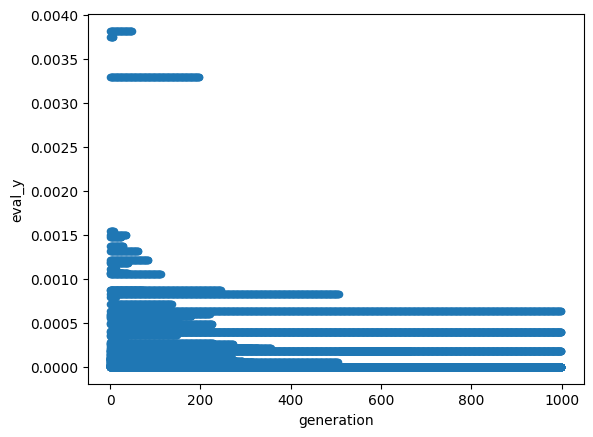

In [11]:
ga.run()
ga.analyse()

### Elitist Strategy

In [12]:
# Initialization
n_generation = 100
n_population = 1000

# Explanatory Parameters
x_uppers: list[float] = [0.2, 0.3, 0.05]
x_lowers: list[float] = [0.1, 0.2, 0.01]
n_dimension = len(x_uppers)

# Target Parameers
target_ys = [0.05]

# Making Class Instance
ga = GeneticAlgorithm(
    n_population=n_population,
    n_generation=n_generation,
    n_dimension=n_dimension,
    x_uppers=x_uppers,
    x_lowers=x_lowers,
    target_ys=target_ys
)

# Select Method
tournament_size = 2     # For Tournament Select
ga.set_select(
    select_name="tournament",
    tournament_size = tournament_size
    )

# Crossover Method
n_parents = 2           # For BLX-a
ga.set_crossover(
    crossover_name="blx_alpha",
    n_parents=n_parents, 
    alpha = 0.3
    )

# Strategy for GA
n_crossover = 5         # For MGG
n_elites = 1            # For Elitist GA
ga.set_strategy(
    "elitist", 
    n_elites=n_elites,
    )

# solver settings
model_path = "./sample_solver/linearregressor.pkl"
ga.initialize(model_path)

*** Num of Generation 100 Initialized 1000 individuals ***


,x_0,x_1,x_2,y_pred,fitness
0,1.02e-01,2.30e-01,4.43e-02,4.02e-02,9.62e-05
1,1.77e-01,2.83e-01,2.41e-02,7.50e-02,6.27e-04
2,1.88e-01,2.32e-01,1.44e-02,6.42e-02,2.01e-04
3,1.72e-01,2.64e-01,2.60e-02,6.56e-02,2.44e-04
4,1.56e-01,2.23e-01,3.23e-02,5.73e-02,5.37e-05


,generation,x_0,x_1,x_2,target_0,eval_y
0,0,1.23e-01,2.93e-01,1.33e-02,5.00e-02,2.10e-10
1,0,1.96e-01,2.39e-01,1.64e-02,6.98e-02,3.91e-04
2,0,1.29e-01,2.22e-01,1.45e-02,3.11e-02,3.58e-04
3,0,1.64e-01,2.20e-01,3.49e-02,7.08e-02,4.32e-04
4,0,1.90e-01,2.68e-01,1.63e-02,7.12e-02,4.50e-04
...,...,...,...,...,...,...
99995,99,1.55e-01,2.57e-01,1.00e-02,4.05e-02,9.01e-05
99996,99,1.54e-01,2.57e-01,1.00e-02,4.01e-02,9.86e-05
99997,99,1.55e-01,2.57e-01,1.00e-02,4.06e-02,8.79e-05
99998,99,1.54e-01,2.58e-01,1.00e-02,4.05e-02,9.06e-05


*** Start to analyze ***
             x_0       x_1       x_2    eval_y
x_0     1.00e+00 -1.80e-02 -9.32e-02  1.00e-02
x_1    -1.80e-02  1.00e+00 -8.24e-02 -2.72e-01
x_2    -9.32e-02 -8.24e-02  1.00e+00  2.97e-01
eval_y  1.00e-02 -2.72e-01  2.97e-01  1.00e+00


,generation,x_0,x_1,x_2,target_0,eval_y
3173,3.00e+00,1.29e-01,2.97e-01,1.92e-02,5.00e-02,2.45e-12


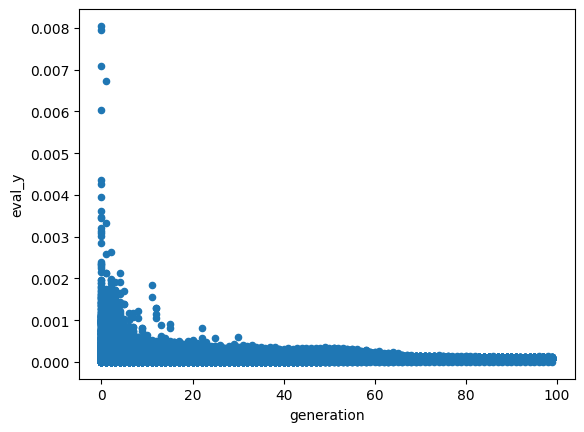

In [13]:
ga.run()
ga.analyse()